Import Libraries

In [60]:
import psycopg2
import networkx as nx
import matplotlib.pyplot as plt
import config
import pandas as pd
from collections import defaultdict
import plotly.graph_objects as go
import community as community_louvain
import matplotlib.cm as cm
import dash
import dash_cytoscape as cyto
import dash_html_components as html
from dash.dependencies import Input, Output
import pickle



Database Connection and Data Retrieval

In [62]:
# Establish a connection to the PostgreSQL database
try:
    connection = psycopg2.connect(
        host=config.host,
        database=config.database,
        user=config.user,
        password=config.password, 
        port=config.port
    )
    print("Connected to the database")

    # Example query to get data: Replace with an appropriate query for your use case
    query = '''
    SELECT puuid, match_id
    FROM playerMatches; 
    '''

    # Create a DataFrame from the query result
    dataframe = pd.read_sql_query(query, connection)

    # Close the database connection
    connection.close()
    print("Connection closed")

except psycopg2.Error as e:
    print("Error connecting to the database:", e)

Connected to the database


C:\Users\Grego\AppData\Roaming\Python\Python39\site-packages\pandas\io\sql.py:762: UserWarning:

pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy



Connection closed


Data Preview

In [63]:
# Preview the retrieved data
dataframe.head()

,puuid,match_id
0,ctfrWOdXHVuv74QM_d5rfq-OYFzLZ8myXCMWsRJIRkFMa2...,NA1_4762036157
1,z-shiYj89cWv_8L6TpVa4cxuwhIV800ZVviNr3fm3WcaEZ...,NA1_4762036157
2,3HP4d1jvJtIfFxDuf1vzTW3ysu9xwLmemz1K30-y-TV9TV...,NA1_4762036157
3,vEaXpidL9Qp0R-mvFNKBZ5B4s-kHmLbNum9XqQp93f1b8W...,NA1_4762036157
4,yc5w0vM-D9k-cBRxqhbzBZyB26yvluwZNJAly69v6QZKaj...,NA1_4762036157


In [64]:
dataframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1326620 entries, 0 to 1326619
Data columns (total 2 columns):
 #   Column    Non-Null Count    Dtype 
---  ------    --------------    ----- 
 0   puuid     1326620 non-null  object
 1   match_id  1326620 non-null  object
dtypes: object(2)
memory usage: 20.2+ MB


Calculate Player Interactions

In [65]:
# Calculate how often players have played together
player_combinations = defaultdict(int)

# Group data by match_id to process players who played in the same match
grouped = dataframe.groupby('match_id')

for name, group in grouped:
    players = group['puuid'].tolist()

    # Increment count for each pair of players in the match
    for i in range(len(players)):
        for j in range(i+1, len(players)):
            # Ensure consistent ordering of player pairs
            pair = tuple(sorted((players[i], players[j])))
            player_combinations[pair] += 1

 Convert to DataFrame and Display

In [66]:
# Convert to DataFrame for easier analysis and export
player_combinations_df = pd.DataFrame(
    list(player_combinations.items()), 
    columns=['player_pair', 'games_played_together']
)

# Preview the resulting DataFrame
player_combinations_df.head()

,player_pair,games_played_together
0,(51tvVdg6gF84PUVby7trDe4NBGihvCun54WTbK1TkcO93...,1
1,(G3lyiAkFzPvA7yqq4DwEGMrVjc3HXXfTy0hWkT4yDryGu...,1
2,(8am086HDuxKewjNKoV__SkQBROCoMv-mqsCZ5R0iILQvp...,1
3,(SdjQHjgEvkfqUc4srJX-2KNSQYBt61CGEf8SGGPomEdHi...,1
4,(NUOIJb8E9FMDaGa7PnoBN0cxknirQ8IzQdqk6VGJPvreT...,1


In [67]:
# Split player_pair tuple into two columns
player_combinations_df[['player1_puuid', 'player2_puuid']] = pd.DataFrame(
    player_combinations_df['player_pair'].tolist(), 
    index=player_combinations_df.index
)

# Preview to ensure 'player1_puuid' and 'player2_puuid' columns are created
player_combinations_df.head()

,player_pair,games_played_together,player1_puuid,player2_puuid
0,(51tvVdg6gF84PUVby7trDe4NBGihvCun54WTbK1TkcO93...,1,51tvVdg6gF84PUVby7trDe4NBGihvCun54WTbK1TkcO93z...,SdjQHjgEvkfqUc4srJX-2KNSQYBt61CGEf8SGGPomEdHir...
1,(G3lyiAkFzPvA7yqq4DwEGMrVjc3HXXfTy0hWkT4yDryGu...,1,G3lyiAkFzPvA7yqq4DwEGMrVjc3HXXfTy0hWkT4yDryGub...,SdjQHjgEvkfqUc4srJX-2KNSQYBt61CGEf8SGGPomEdHir...
2,(8am086HDuxKewjNKoV__SkQBROCoMv-mqsCZ5R0iILQvp...,1,8am086HDuxKewjNKoV__SkQBROCoMv-mqsCZ5R0iILQvpA...,SdjQHjgEvkfqUc4srJX-2KNSQYBt61CGEf8SGGPomEdHir...
3,(SdjQHjgEvkfqUc4srJX-2KNSQYBt61CGEf8SGGPomEdHi...,1,SdjQHjgEvkfqUc4srJX-2KNSQYBt61CGEf8SGGPomEdHir...,V66LlDjEFVJW8GEUFAfcCW4RLiEqW1OXWLgAG7azPReYVt...
4,(NUOIJb8E9FMDaGa7PnoBN0cxknirQ8IzQdqk6VGJPvreT...,1,NUOIJb8E9FMDaGa7PnoBN0cxknirQ8IzQdqk6VGJPvreT2...,SdjQHjgEvkfqUc4srJX-2KNSQYBt61CGEf8SGGPomEdHir...


In [68]:
# Establish a connection to the PostgreSQL database
try:
    connection = psycopg2.connect(
        host=config.host,
        database=config.database,
        user=config.user,
        password=config.password, 
        port=config.port
    )
    print("Connected to the database")

    # Ensure 'player_combinations_df' has 'player1_puuid' and 'player2_puuid'
    # If not, ensure the previous steps have been executed correctly
    
    # Extract unique puuids from player_combinations_df
    unique_puuids = pd.concat([
        player_combinations_df['player1_puuid'], 
        player_combinations_df['player2_puuid']
    ]).unique()
    unique_puuids_str = ','.join(f"'{puuid}'" for puuid in unique_puuids)

    # Query to get player names and puuids
    query = f'SELECT puuid, summoner_name FROM player WHERE puuid IN ({unique_puuids_str});'

    # Crea  te a DataFrame from the query result
    player_df = pd.read_sql_query(query, connection)

    # Close the database connection
    connection.close()
    print("Connection closed")

except psycopg2.Error as e:
    print("Error connecting to the database:", e)

Connected to the database


C:\Users\Grego\AppData\Roaming\Python\Python39\site-packages\pandas\io\sql.py:762: UserWarning:

pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy



Connection closed


In [69]:
# Map the puuids to summoner names
player_combinations_df['player1_name'] = player_combinations_df['player1_puuid'].map(
    player_df.set_index('puuid')['summoner_name']
)
player_combinations_df['player2_name'] = player_combinations_df['player2_puuid'].map(
    player_df.set_index('puuid')['summoner_name']
)

# Drop the unnecessary columns
player_combinations_df = player_combinations_df.drop(columns=['player_pair', 'player1_puuid', 'player2_puuid'])

# Preview the DataFrame
player_combinations_df.head()

,games_played_together,player1_name,player2_name
0,1,lixc,notstandard
1,1,tel,notstandard
2,1,813988,notstandard
3,1,notstandard,chronokatz
4,1,thisnameistrash,notstandard


In [70]:
player_combinations_df['games_played_together'].value_counts()

1      5232361
2       145368
3        29157
4        11054
5         6025
        ...   
173          1
149          1
203          1
168          1
193          1
Name: games_played_together, Length: 243, dtype: int64

In [73]:
player_combinations_df.isnull().sum()

games_played_together    0
player1_name             0
player2_name             0
dtype: int64

In [72]:
player_combinations_df = player_combinations_df.dropna()

In [40]:
player_combinations_df.head()

,games_played_together
0,1
1,1
2,1
3,1
4,1


In [74]:
# Initialize graph
G = nx.Graph()

# Add edges to the graph
for index, row in player_combinations_df.iterrows():
    # Add an edge between player1 and player2
    # Use the games_played_together as the 'weight' attribute
    G.add_edge(row['player1_name'], row['player2_name'], weight=row['games_played_together'])

In [76]:
nx.write_gpickle(G, "huge_graph.gpickle")

AttributeError: module 'networkx' has no attribute 'write_gpickle'

In [ ]:
# G = nx.read_gpickle("huge_graph.gpickle")

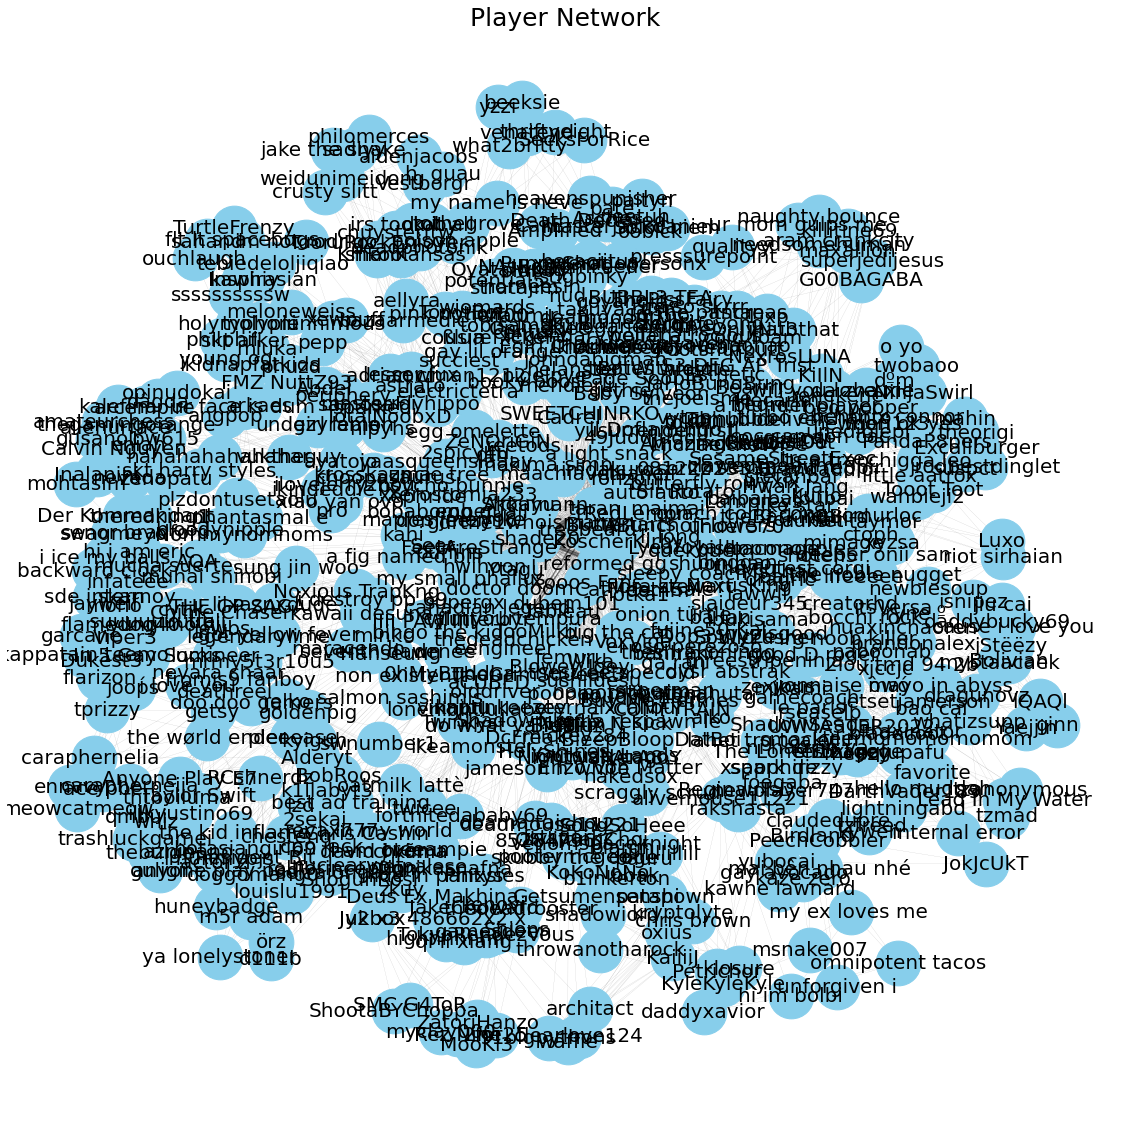

In [ ]:
plt.figure(figsize=(20, 20))
pos = nx.spring_layout(G, seed=42, k=0.35)

# Draw nodes
nx.draw_networkx_nodes(G, pos, node_color="skyblue", node_size=2000)

# Draw edges with transparency and dynamic width
for (u, v, wt) in G.edges.data('weight'):
    nx.draw_networkx_edges(G, pos, edgelist=[(u, v)], width=wt*0.1, alpha=0.5)

# Draw labels
nx.draw_networkx_labels(G, pos, font_size=20)

plt.title("Player Network", size=25)
plt.axis("off")  # Hide axis
plt.show()


NetworkXError: Node 'shade20' has no position.

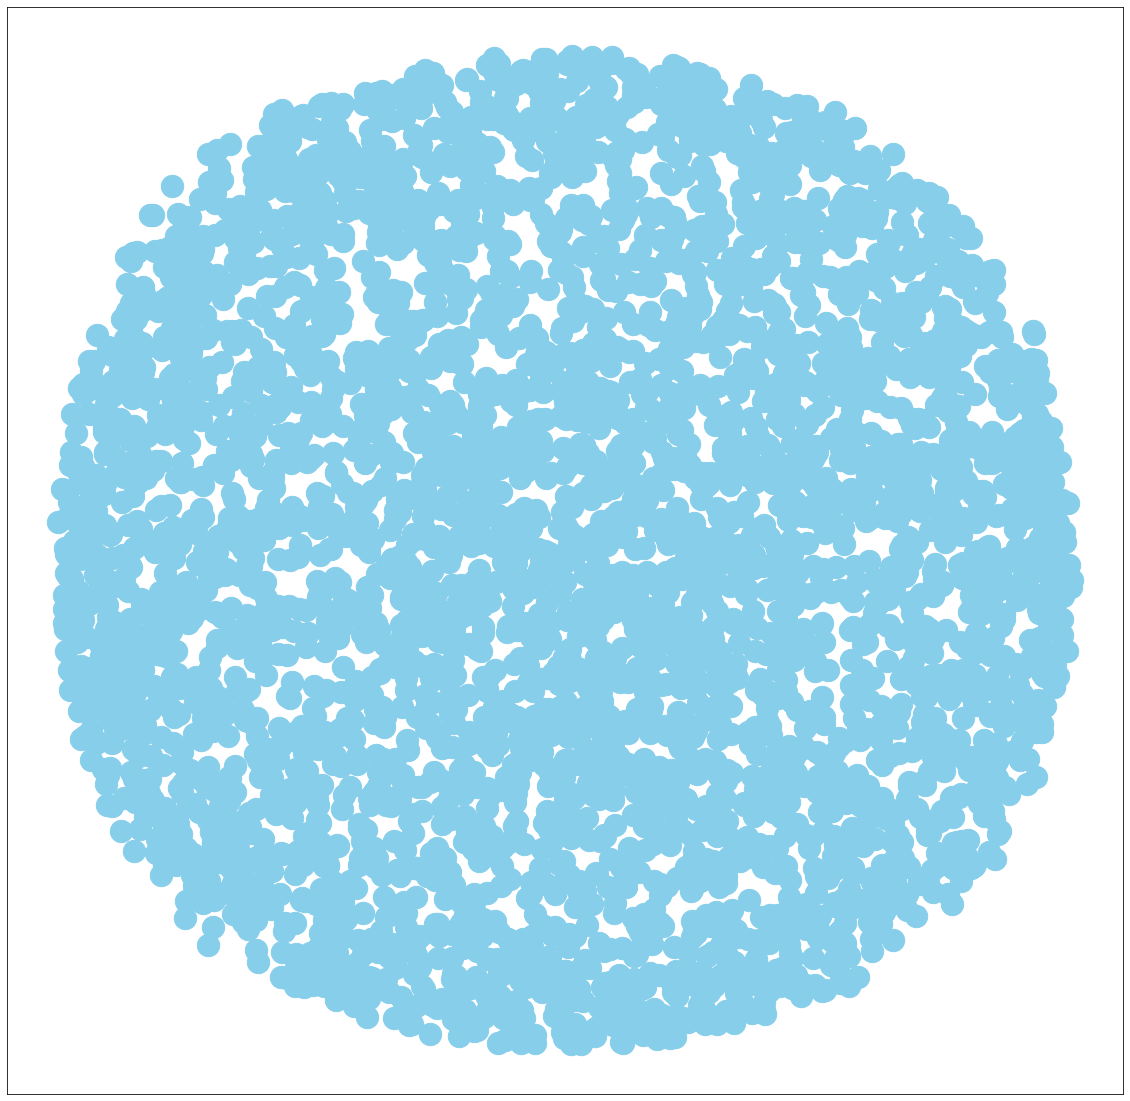

In [9]:
plt.figure(figsize=(20, 20))
pos = nx.spring_layout(G, seed=42, k=0.35)

# Draw nodes
nx.draw_networkx_nodes(G, pos, node_color="skyblue", node_size=500)

# Draw shade20 node in a different color and size
nx.draw_networkx_nodes(G, pos, nodelist=["shade20"], node_color="red", node_size=600)

# Draw edges with transparency and dynamic width
for (u, v, wt) in G.edges.data('weight'):
    nx.draw_networkx_edges(G, pos, edgelist=[(u, v)], width=wt*0.1, alpha=0.5)

# Highlight edges for shade20
highlight_edges = [(u, v) for (u, v, wt) in G.edges.data('weight') if "shade20" in (u, v)]
nx.draw_networkx_edges(G, pos, edgelist=highlight_edges, width=2, edge_color="red", alpha=0.7)

# Draw labels
nx.draw_networkx_labels(G, pos, font_size=20)

plt.title("Player Network", size=25)
plt.axis("off")  # Hide axis
plt.show()


In [75]:
# Positioning
pos = nx.spring_layout(G, seed=42)

# Create edge trace
edge_x = []
edge_y = []
for edge in G.edges():
    x0, y0 = pos[edge[0]]
    x1, y1 = pos[edge[1]]
    edge_x.append(x0)
    edge_x.append(x1)
    edge_x.append(None)
    edge_y.append(y0)
    edge_y.append(y1)
    edge_y.append(None)

edge_trace = go.Scatter(
    x=edge_x, y=edge_y,
    line=dict(width=0.5, color='#888'),
    hoverinfo='none',
    mode='lines')

# Create node trace
node_x = []
node_y = []
node_text = []
for node in G.nodes():
    x, y = pos[node]
    node_x.append(x)
    node_y.append(y)
    node_text.append(f'Name: {node}')  # node here should be the player name

node_trace = go.Scatter(
    x=node_x, y=node_y,
    mode='markers',
    hoverinfo='text',
    text=node_text,  # this line sets the hover text
    marker=dict(
        showscale=True,
        colorscale='YlGnBu',
        colorbar=dict(
            thickness=15,
            title='Node Connections',
            xanchor='left',
            titleside='right'
        ),
        line_width=2))

# Color node points by the number of connections
node_adjacencies = []
for node, adjacencies in enumerate(G.adjacency()):
    node_adjacencies.append(len(adjacencies[1]))

node_trace.marker.color = node_adjacencies

# Create figure
fig = go.Figure(data=[edge_trace, node_trace],
             layout=go.Layout(
                showlegend=False,
                hovermode='closest',
                margin=dict(b=0, l=0, r=0, t=0),
                xaxis=dict(showgrid=False, zeroline=False),
                yaxis=dict(showgrid=False, zeroline=False))
                )
fig.show()

KeyboardInterrupt: 

In [ ]:
# Create a Dash app
app = dash.Dash(__name__)

# Create a cytoscape graph
app.layout = html.Div([
    cyto.Cytoscape(
        id='cytoscape',
        elements=[{"data": {"id": str(node)}} for node in G.nodes()] + [{"data": {"source": str(source), "target": str(target)}} for source, target in G.edges()],
        layout={'name': 'circle'},
        style={'width': '100%', 'height': '400px'}
    ),
    html.P(id='cytoscape-output')
])

# Callback to display node ID when clicked
@app.callback(Output('cytoscape-output', 'children'), Input('cytoscape', 'tapNodeData'))
def display_tap_node(data):
    if data is None:
        return "Click on a node"
    return f"You clicked on node: {data['id']}"

# Run the app
if __name__ == '__main__':
    app.run_server(debug=True)

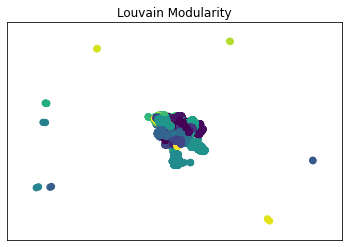

In [61]:
# compute the best partition using Louvain method
partition = community_louvain.best_partition(G)


In [ ]:
# Save the partition using pickle
with open('huge_partition.pkl', 'wb') as f:
    pickle.dump(partition, f)

In [ ]:
with open('huge_partition.pkl', 'rb') as f:
    partition = pickle.load(f)

In [ ]:
# Positioning
pos = nx.spring_layout(G, seed=42)

# Create edge trace
edge_trace = go.Scatter(
    x=[],
    y=[],
    line=dict(width=0.5, color='#888'),
    hoverinfo='none',
    mode='lines')

for edge in G.edges():
    x0, y0 = pos[edge[0]]
    x1, y1 = pos[edge[1]]
    edge_trace['x'] += [x0, x1, None]
    edge_trace['y'] += [y0, y1, None]

# Create node trace
node_trace = go.Scatter(
    x=[],
    y=[],
    text=[],
    mode='markers',
    hoverinfo='text',
    marker=dict(
        showscale=True,
        colorscale='Viridis',
        colorbar=dict(
            thickness=15,
            title='Node Connections',
            xanchor='left',
            titleside='right'
        ),
        line_width=2))

for node in G.nodes():
    x, y = pos[node]
    node_trace['x'] += tuple([x])
    node_trace['y'] += tuple([y])
    node_trace['text'] += tuple([f'Name: {node}'])

# Color node points by the partition (community)
node_trace.marker.color = list(partition.values())

# Create figure
fig = go.Figure(data=[edge_trace, node_trace],
             layout=go.Layout(
                title='Network Visualization with Communities',
                titlefont_size=16,
                showlegend=False,
                hovermode='closest',
                margin=dict(b=0, l=0, r=0, t=0),
                xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
                yaxis=dict(showgrid=False, zeroline=False, showticklabels=False))
                )

fig.show()

In [ ]:
# Create a DataFrame from the partition
cluster_df = pd.DataFrame(list(partition.items()), columns=['puuid', 'cluster_id'])

In [ ]:
def get_avg_performance_metrics(connection, cluster_df):
    query = """
    SELECT p.puuid, 
           AVG(pm.kills) AS avg_kills, 
           AVG(pm.deaths) AS avg_deaths, 
           AVG(pm.assists) AS avg_assists
    FROM playerMatches pm
    JOIN player p ON pm.puuid = p.puuid
    GROUP BY p.puuid;
    """
    player_metrics_df = pd.read_sql_query(query, connection)
    merged_df = pd.merge(cluster_df, player_metrics_df, on='puuid', how='inner')
    return merged_df.groupby('cluster_id').mean()

In [ ]:
def get_champion_preferences(connection, cluster_df):
    query = """
    SELECT p.puuid, 
           pm.championName, 
           COUNT(*) AS games_played
    FROM playerMatches pm
    JOIN player p ON pm.puuid = p.puuid
    GROUP BY p.puuid, pm.championName;
    """
    champion_df = pd.read_sql_query(query, connection)
    merged_df = pd.merge(cluster_df, champion_df, on='puuid', how='inner')
    return merged_df.groupby(['cluster_id', 'championName']).sum().reset_index()


In [ ]:
def get_win_ratio(connection, cluster_df):
    query = """
    SELECT p.puuid, 
           AVG(CASE WHEN pm.win THEN 1.0 ELSE 0.0 END) AS win_ratio
    FROM playerMatches pm
    JOIN player p ON pm.puuid = p.puuid
    GROUP BY p.puuid;
    """
    win_ratio_df = pd.read_sql_query(query, connection)
    merged_df = pd.merge(cluster_df, win_ratio_df, on='puuid', how='inner')
    return merged_df.groupby('cluster_id').mean()

In [ ]:
# Establish a connection to the PostgreSQL database
connection = psycopg2.connect(
        host=config.host,
        database=config.database,
        user=config.user,
        password=config.password, 
        port=config.port
    )

# Example cluster DataFrame
# cluster_df = pd.DataFrame(list(partition.items()), columns=['puuid', 'cluster_id'])

# Usage of the functions
avg_metrics_by_cluster = get_avg_performance_metrics(connection, cluster_df)
champion_preferences_by_cluster = get_champion_preferences(connection, cluster_df)
win_ratio_by_cluster = get_win_ratio(connection, cluster_df)

# Close the connection
connection.close()

In [ ]:
print(f'avg_metrics_by_cluster: {avg_metrics_by_cluster}\nchampion_preferences_by_cluster: {champion_preferences_by_cluster}\nwin_ratio_by_cluster: {win_ratio_by_cluster}')